In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

DATA_ROOT = "/content/drive/MyDrive/ML2026/data/nutrition5k_dataset"

paths = [
    "metadata",
    "dish_ids/splits",
    "imagery/realsense_overhead"
]

for path in paths:
    full_path = os.path.join(DATA_ROOT, path)
    print(path, "exists:", os.path.exists(full_path))

metadata_path = os.path.join(DATA_ROOT, "metadata")
print("Metadata files:", os.listdir(metadata_path))

split_path = os.path.join(DATA_ROOT, "dish_ids/splits")
print("Split files:", os.listdir(split_path))

image_path = os.path.join(DATA_ROOT, "imagery/realsense_overhead")
print("Sample dish folders:", os.listdir(image_path)[:5])

metadata exists: True
dish_ids/splits exists: True
imagery/realsense_overhead exists: True
Metadata files: ['ingredients_metadata.csv', 'dish_metadata_cafe2.csv', 'dish_metadata_cafe1.csv']
Split files: ['depth_train_ids.txt', 'rgb_train_ids.txt', 'depth_test_ids.txt', 'rgb_test_ids.txt']
Sample dish folders: ['dish_1560798744', 'dish_1560798707', 'dish_1560787817', 'dish_1560788384', 'dish_1560798656']


In [ ]:
import os
import cv2
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image


class Nutrition5kRgbDepthDataset(Dataset):
    def __init__(self, csv_path, image_root):
        self.data = pd.read_csv(csv_path)
        self.image_root = image_root

        self.rgb_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.data)

    def find_files(self, dish_id):
        dish_folder = os.path.join(self.image_root, dish_id)

        if not os.path.exists(dish_folder):
            return None, None

        rgb_path = None
        depth_path = None

        for file_name in os.listdir(dish_folder):
            lower_name = file_name.lower()
            full_path = os.path.join(dish_folder, file_name)

            if "rgb" in lower_name and file_name.endswith((".png", ".jpg", ".jpeg")):
                rgb_path = full_path

            if "depth_raw" in lower_name or ("depth" in lower_name and "color" not in lower_name):
                depth_path = full_path

        return rgb_path, depth_path

    def __getitem__(self, index):
        row = self.data.iloc[index]
        dish_id = row["dish_id"]

        rgb_path, depth_path = self.find_files(dish_id)

        if rgb_path is None:
            raise FileNotFoundError(f"No RGB image found for {dish_id}")

        if depth_path is None:
            raise FileNotFoundError(f"No depth image found for {dish_id}")

        rgb_image = Image.open(rgb_path).convert("RGB")
        rgb_tensor = self.rgb_transform(rgb_image)

        depth_image = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED).astype(np.float32)

        # Nutrition5k depth scale
        depth_image = depth_image / 10000.0

        depth_image = cv2.resize(depth_image, (224, 224))

        # Normalize depth safely
        depth_min = np.min(depth_image)
        depth_max = np.max(depth_image)

        if depth_max > depth_min:
            depth_image = (depth_image - depth_min) / (depth_max - depth_min)

        depth_tensor = torch.tensor(depth_image, dtype=torch.float32).unsqueeze(0)

        target = torch.tensor([row["total_calories"]], dtype=torch.float32)

        return rgb_tensor, depth_tensor, target

In [ ]:
import os
import csv
import pandas as pd

root_path = "/content/drive/MyDrive/ML2026/data/nutrition5k_dataset"
mFile = os.path.join(root_path, "metadata", "dish_metadata_cafe1.csv")
iRoot = os.path.join(root_path, "imagery", "realsense_overhead")

items = []

def has_rgb_and_depth(d_id):
    dF = os.path.join(iRoot, d_id)

    if not os.path.exists(dF):
        print(dF)
        return False
    eF = os.listdir(dF)
    valid_rggb = any(
        "rgb" in file.lower() and file.lower().endswith((".png", ".jpg", ".jpeg"))
        for file in eF
    )
    # for i in range(len(eF)):
    #     print(eF[i])
    # print(valid_rggb)
    valid_depth = any(
        "depth_raw" in file.lower() or ("depth" in file.lower() and "color" not in file.lower())
        for file in eF
    )
    return valid_rggb and valid_depth

with open(mFile, "r", encoding="utf-8") as file:
    fR = csv.reader(file)
    for row in fR:
        dish_id = row[0]
        if not has_rgb_and_depth(dish_id):
            continue
        items.append({
            "dish_id": dish_id,
            "total_calories": float(row[1]),
            "total_mass": float(row[2]),
            "total_fat": float(row[3]),
            "total_carb": float(row[4]),
            "total_protein": float(row[5])
        })
df = pd.DataFrame(items)
# print("Total dishes:", len(df))
# print(df.head())
os.makedirs("data", exist_ok=True)
df.to_csv("data/metadata_clean.csv", index=False)
print("File created after cleaning the metadata:metadata_clean.csv")

/content/drive/MyDrive/ML2026/data/nutrition5k_dataset/imagery/realsense_overhead/dish_1562688426
/content/drive/MyDrive/ML2026/data/nutrition5k_dataset/imagery/realsense_overhead/dish_1563379132
/content/drive/MyDrive/ML2026/data/nutrition5k_dataset/imagery/realsense_overhead/dish_1565640549
/content/drive/MyDrive/ML2026/data/nutrition5k_dataset/imagery/realsense_overhead/dish_1563207364
/content/drive/MyDrive/ML2026/data/nutrition5k_dataset/imagery/realsense_overhead/dish_1550795690
/content/drive/MyDrive/ML2026/data/nutrition5k_dataset/imagery/realsense_overhead/dish_1563216717
/content/drive/MyDrive/ML2026/data/nutrition5k_dataset/imagery/realsense_overhead/dish_1565972591
/content/drive/MyDrive/ML2026/data/nutrition5k_dataset/imagery/realsense_overhead/dish_1568649312
/content/drive/MyDrive/ML2026/data/nutrition5k_dataset/imagery/realsense_overhead/dish_1550876012
/content/drive/MyDrive/ML2026/data/nutrition5k_dataset/imagery/realsense_overhead/dish_1551565034
/content/drive/MyDri

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights


class DepthEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.depth_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.fc = nn.Linear(64, 128)

    def forward(self, depth):
        depth_features = self.depth_layers(depth)
        depth_features = depth_features.view(depth_features.size(0), -1)
        depth_features = self.fc(depth_features)
        return depth_features


class RgbDepthCaloriePredictor(nn.Module):
    def __init__(self):
        super().__init__()

        self.rgb_model = resnet18(weights=ResNet18_Weights.DEFAULT)
        rgb_features = self.rgb_model.fc.in_features
        self.rgb_model.fc = nn.Identity()

        self.depth_model = DepthEncoder()

        self.regressor = nn.Sequential(
            nn.Linear(rgb_features + 128, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, rgb, depth):
        rgb_features = self.rgb_model(rgb)
        depth_features = self.depth_model(depth)

        combined_features = torch.cat([rgb_features, depth_features], dim=1)

        output = self.regressor(combined_features)
        return output

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split


DATA_ROOT = "/content/drive/MyDrive/ML2026/data/nutrition5k_dataset"
CSV_PATH = "/content/drive/MyDrive/ML2026/data/metadata_clean.csv"
IMAGE_ROOT = os.path.join(DATA_ROOT, "imagery/realsense_overhead")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset = Nutrition5kRgbDepthDataset(CSV_PATH, IMAGE_ROOT)

subset_size = min(1000, len(dataset))
dataset, _ = random_split(dataset, [subset_size, len(dataset) - subset_size])

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

model = RgbDepthCaloriePredictor().to(device)

loss_function = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 5

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for rgb, depth, target in train_loader:
        rgb = rgb.to(device)
        depth = depth.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        prediction = model(rgb, depth)
        loss = loss_function(prediction, target)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_test_loss = 0

    with torch.no_grad():
        for rgb, depth, target in test_loader:
            rgb = rgb.to(device)
            depth = depth.to(device)
            target = target.to(device)

            prediction = model(rgb, depth)
            loss = loss_function(prediction, target)

            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(test_loader)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train MAE: {avg_train_loss:.2f} | "
        f"Test MAE: {avg_test_loss:.2f}"
    )

torch.save(model.state_dict(), "rgb_depth_calorie_predictor.pth")
print("Saved model as rgb_depth_calorie_predictor.pth")

Using device: cuda
Epoch [1/5] Train MAE: 196.55 | Test MAE: 156.51
Epoch [2/5] Train MAE: 117.94 | Test MAE: 82.18
Epoch [3/5] Train MAE: 90.26 | Test MAE: 63.40
Epoch [4/5] Train MAE: 82.98 | Test MAE: 56.18
Epoch [5/5] Train MAE: 77.88 | Test MAE: 54.09
Saved model as rgb_depth_calorie_predictor.pth


Dish ID: dish_1559751458


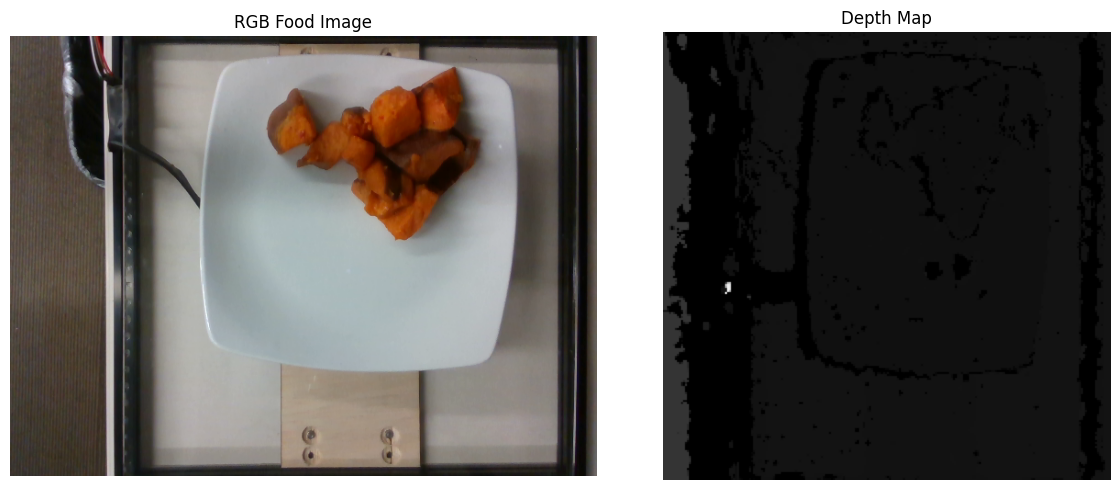


========== RESULTS ==========
Actual Calories    : 152.64
Predicted Calories : 109.21
Absolute Error     : 43.44


In [ ]:
import os
import cv2
import torch
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
from torchvision import transforms



# DATA_ROOT = "data/nutrition5k_dataset"
# CSV_PATH = "data/metadata_clean.csv"
IMAGE_ROOT = os.path.join(DATA_ROOT, "imagery", "realsense_overhead")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Load trained model
# -----------------------------
model = RgbDepthCaloriePredictor().to(device)
model.load_state_dict(torch.load("rgb_depth_calorie_predictor.pth", map_location=device))
model.eval()

# -----------------------------
# Load metadata
# -----------------------------
df = pd.read_csv(CSV_PATH)

# Random sample
sample = df.sample(1).iloc[0]

dish_id = sample["dish_id"]
actual_calories = sample["total_calories"]

dish_folder = os.path.join(IMAGE_ROOT, dish_id)

rgb_path = None
depth_path = None

for file_name in os.listdir(dish_folder):
    lower_name = file_name.lower()

    full_path = os.path.join(dish_folder, file_name)

    if "rgb" in lower_name and file_name.endswith((".png", ".jpg", ".jpeg")):
        rgb_path = full_path

    if "depth_raw" in lower_name or ("depth" in lower_name and "color" not in lower_name):
        depth_path = full_path

print("Dish ID:", dish_id)

# -----------------------------
# RGB preprocessing
# -----------------------------
rgb_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

rgb_image_pil = Image.open(rgb_path).convert("RGB")
rgb_tensor = rgb_transform(rgb_image_pil).unsqueeze(0).to(device)

# -----------------------------
# Depth preprocessing
# -----------------------------
depth_image = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED).astype(np.float32)

depth_image = depth_image / 10000.0

depth_image = cv2.resize(depth_image, (224, 224))

depth_min = np.min(depth_image)
depth_max = np.max(depth_image)

if depth_max > depth_min:
    depth_image = (depth_image - depth_min) / (depth_max - depth_min)

depth_tensor = torch.tensor(depth_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# -----------------------------
# Prediction
# -----------------------------
with torch.no_grad():
    prediction = model(rgb_tensor, depth_tensor)

predicted_calories = prediction.item()

# -----------------------------
# Visualization
# -----------------------------
rgb_display = np.array(rgb_image_pil)

plt.figure(figsize=(12, 5))

# RGB Image
plt.subplot(1, 2, 1)
plt.imshow(rgb_display)
plt.title("RGB Food Image")
plt.axis("off")

# Depth Map
plt.subplot(1, 2, 2)
plt.imshow(depth_image, cmap="gray")
plt.title("Depth Map")
plt.axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# Results
# -----------------------------
print("\n========== RESULTS ==========")
print(f"Actual Calories    : {actual_calories:.2f}")
print(f"Predicted Calories : {predicted_calories:.2f}")
print(f"Absolute Error     : {abs(actual_calories - predicted_calories):.2f}")

In [ ]:
pip install timm

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


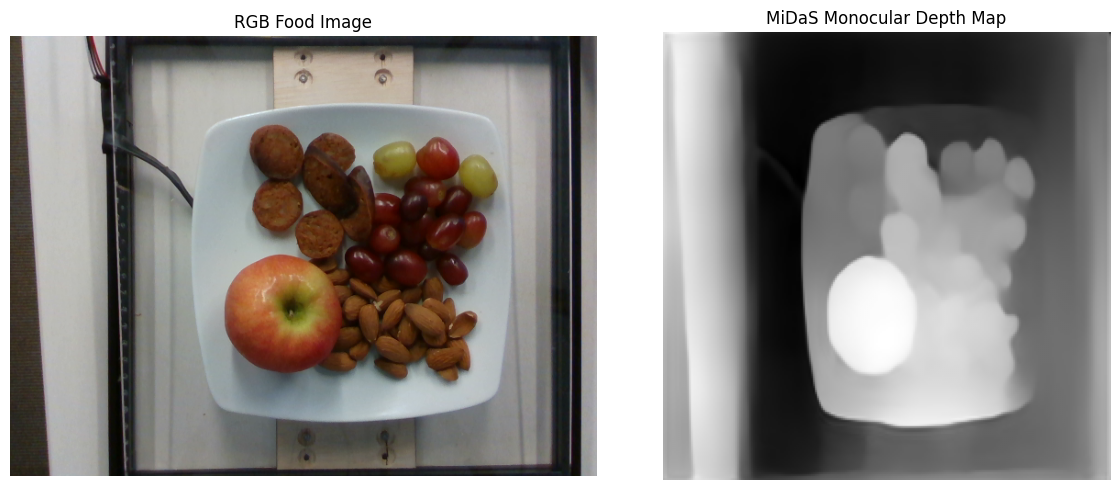


========== MONOCULAR DEPTH RESULT ==========
Dish ID            : dish_1558372771
Actual Calories    : 522.61
Predicted Calories : 637.80
Absolute Error     : 115.19


In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

DATA_ROOT = "/content/drive/MyDrive/ML2026/data/nutrition5k_dataset"
CSV_PATH = "/content/drive/MyDrive/ML2026/data/metadata_clean.csv"
IMAGE_ROOT = os.path.join(DATA_ROOT, "imagery/realsense_overhead")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load nutrition model
nutrition_model = RgbDepthCaloriePredictor().to(device)
nutrition_model.load_state_dict(torch.load("rgb_depth_calorie_predictor.pth", map_location=device))
nutrition_model.eval()

# Load MiDaS depth model
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.to(device)
midas.eval()

midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
midas_transform = midas_transforms.small_transform

# Pick sample dish
df = pd.read_csv(CSV_PATH)
sample = df.sample(1).iloc[0]

dish_id = sample["dish_id"]
actual_calories = sample["total_calories"]
dish_folder = os.path.join(IMAGE_ROOT, dish_id)

rgb_path = None

for file_name in os.listdir(dish_folder):
    lower_name = file_name.lower()
    if "rgb" in lower_name and file_name.lower().endswith((".png", ".jpg", ".jpeg")):
        rgb_path = os.path.join(dish_folder, file_name)
        break

if rgb_path is None:
    raise FileNotFoundError(f"No RGB image found for {dish_id}")

# Load RGB
rgb_image = Image.open(rgb_path).convert("RGB")
rgb_np = np.array(rgb_image)

# RGB for nutrition model
rgb_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

rgb_tensor = rgb_transform(rgb_image).unsqueeze(0).to(device)

# Predict monocular depth using MiDaS
input_batch = midas_transform(rgb_np).to(device)

with torch.no_grad():
    midas_prediction = midas(input_batch)

    midas_prediction = torch.nn.functional.interpolate(
        midas_prediction.unsqueeze(1),
        size=(224, 224),
        mode="bicubic",
        align_corners=False,
    ).squeeze()

predicted_depth = midas_prediction.cpu().numpy()

# Normalize predicted depth to 0–1
depth_min = predicted_depth.min()
depth_max = predicted_depth.max()

if depth_max > depth_min:
    predicted_depth = (predicted_depth - depth_min) / (depth_max - depth_min)

depth_tensor = torch.tensor(
    predicted_depth,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0).to(device)

# Predict calories using RGB + MiDaS depth
with torch.no_grad():
    prediction = nutrition_model(rgb_tensor, depth_tensor)

predicted_calories = prediction.item()

# Show result
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_np)
plt.title("RGB Food Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(predicted_depth, cmap="gray")
plt.title("MiDaS Monocular Depth Map")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\n========== MONOCULAR DEPTH RESULT ==========")
print(f"Dish ID            : {dish_id}")
print(f"Actual Calories    : {actual_calories:.2f}")
print(f"Predicted Calories : {predicted_calories:.2f}")
print(f"Absolute Error     : {abs(actual_calories - predicted_calories):.2f}")

Dataset shape: (1620, 6)
           dish_id  total_calories  total_mass  total_fat  total_carb  \
0  dish_1561662216      300.794281       193.0  12.387489   28.218290   
1  dish_1561662054      419.438782       292.0  23.838249   26.351543   
2  dish_1562008979      382.936646       290.0  22.224644   10.173570   
3  dish_1560455030       20.590000       103.0   0.148000    4.625000   
4  dish_1558372433       74.360001       143.0   0.286000    0.429000   

   total_protein  
0      18.633970  
1      25.910593  
2      35.345387  
3       0.956000  
4      20.020000  
       total_calories   total_mass    total_fat   total_carb  total_protein
count     1620.000000  1620.000000  1620.000000  1620.000000    1620.000000
mean       206.049744   172.490123    10.482131    17.912746      12.450709
std        212.000787   145.680777    13.339674    25.809621      15.065293
min          0.000000     1.000000     0.000000     0.000000       0.000000
25%         55.763988    73.000000     0.2

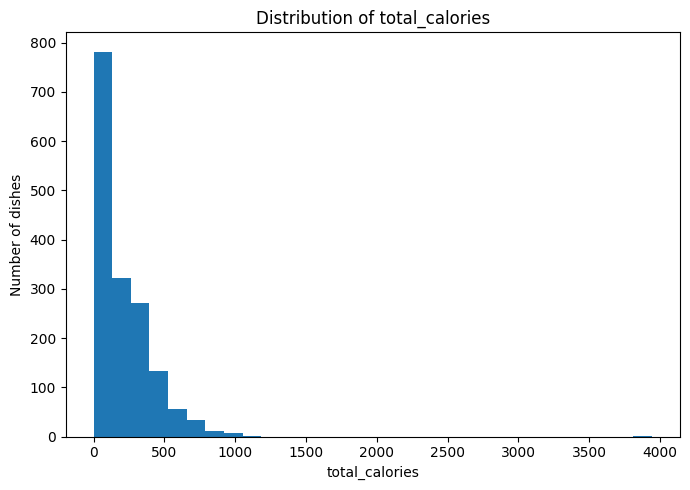

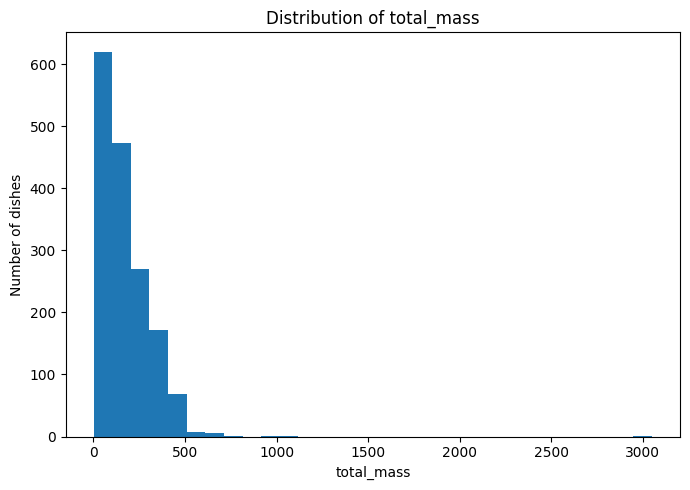

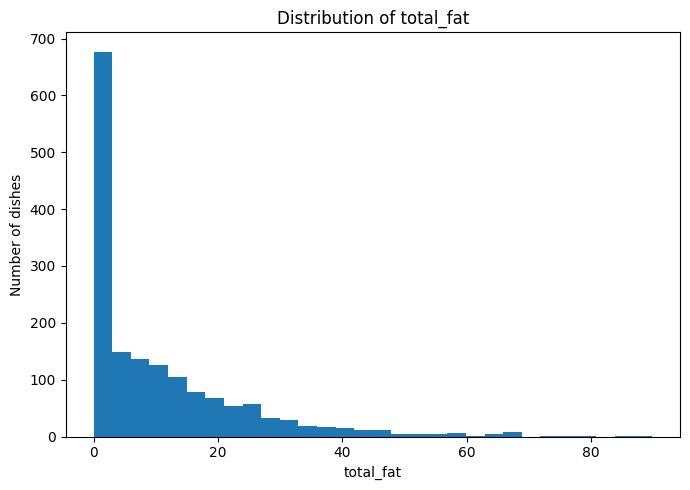

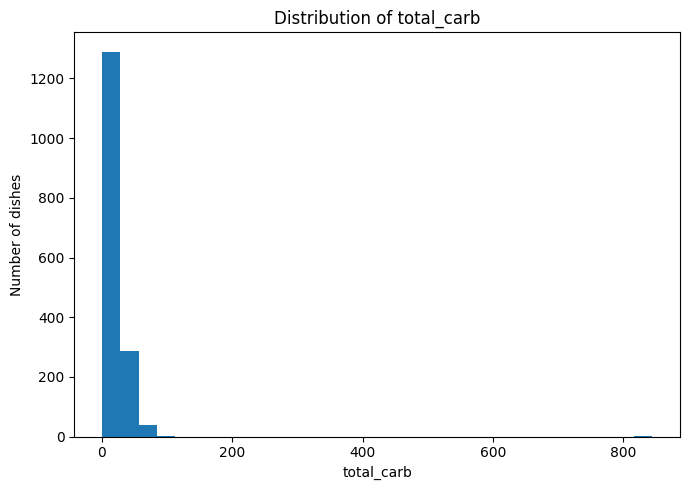

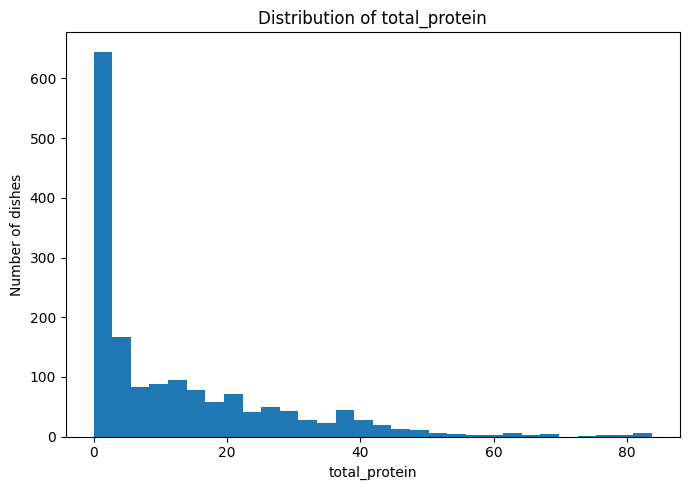

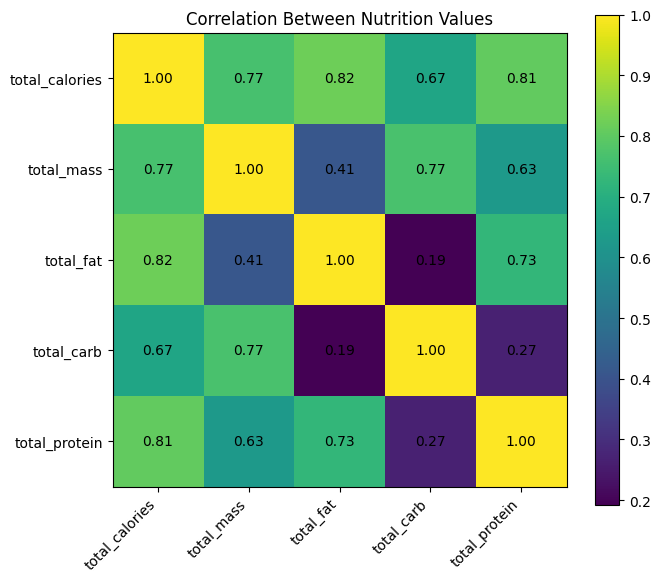

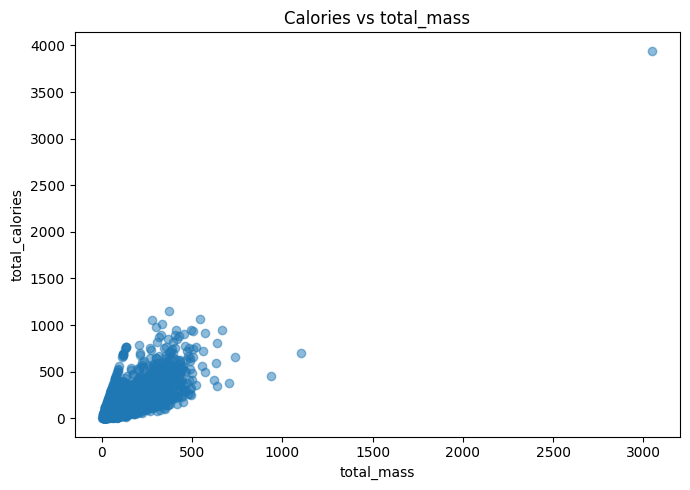

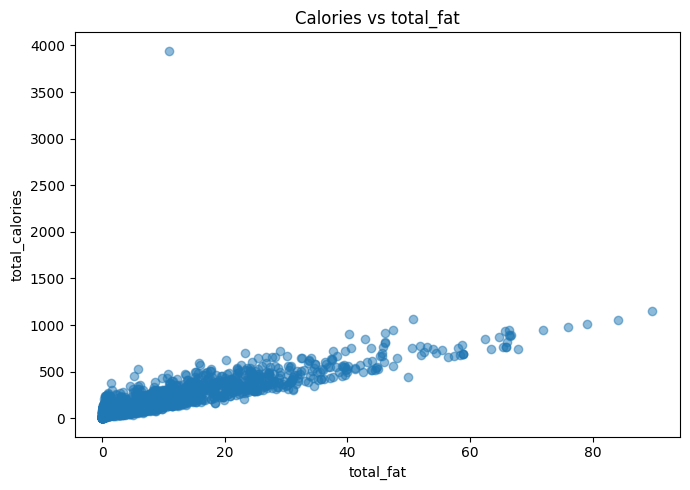

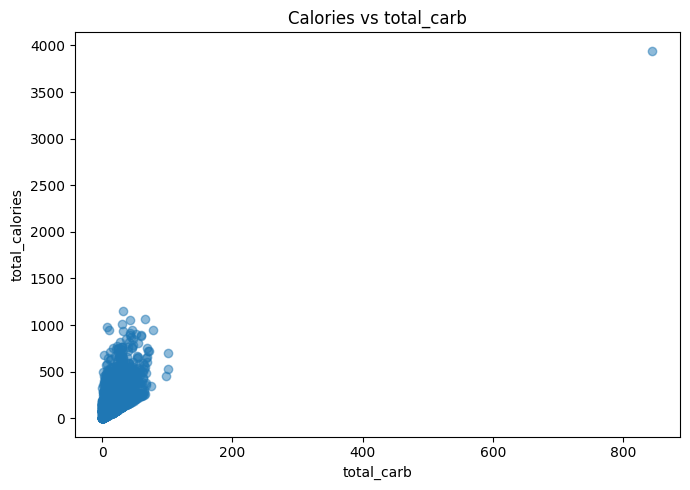

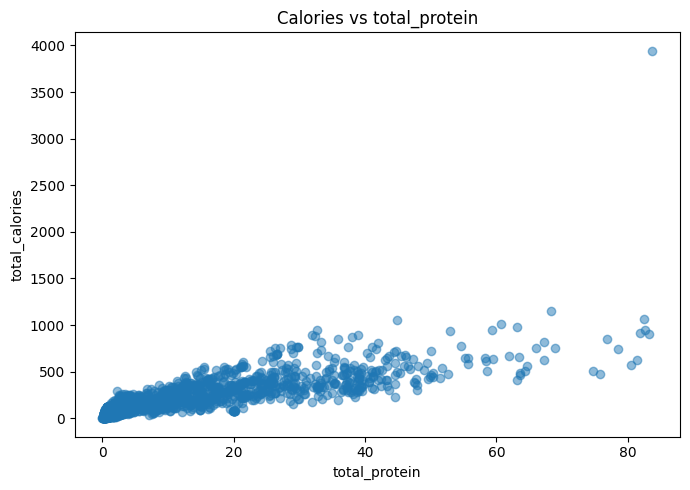


Depth Feature Data:
           dish_id  mean_depth  min_depth  max_depth  depth_range  \
0  dish_1561662216    0.370307     0.2796     6.5535       6.2739   
1  dish_1561662054    0.365620     0.3022     1.1530       0.8508   
2  dish_1562008979    0.363888     0.2633     5.0114       4.7481   
3  dish_1560455030    0.436043     0.2974     1.9239       1.6265   
4  dish_1558372433    0.394667     0.2993     0.4546       0.1553   

   relative_volume_score  total_calories  total_mass  total_fat  total_carb  \
0           90483.523438      300.794281       193.0  12.387489   28.218290   
1           93617.742188      419.438782       292.0  23.838249   26.351543   
2           91935.484375      382.936646       290.0  22.224644   10.173570   
3           92581.601562       20.590000       103.0   0.148000    4.625000   
4          103012.093750       74.360001       143.0   0.286000    0.429000   

   total_protein  
0      18.633970  
1      25.910593  
2      35.345387  
3       0.956

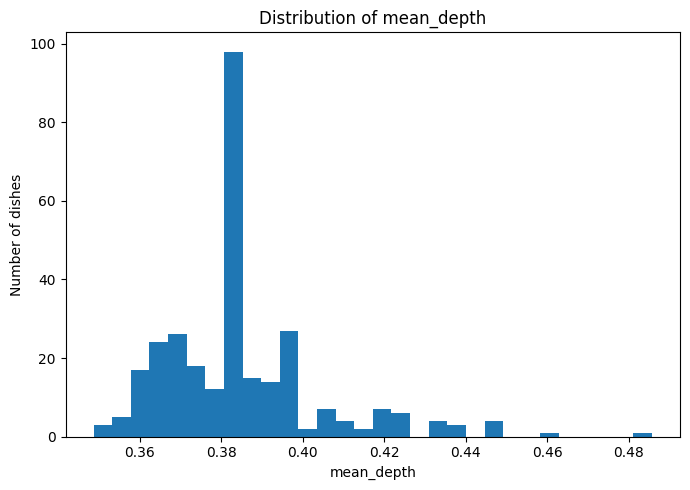

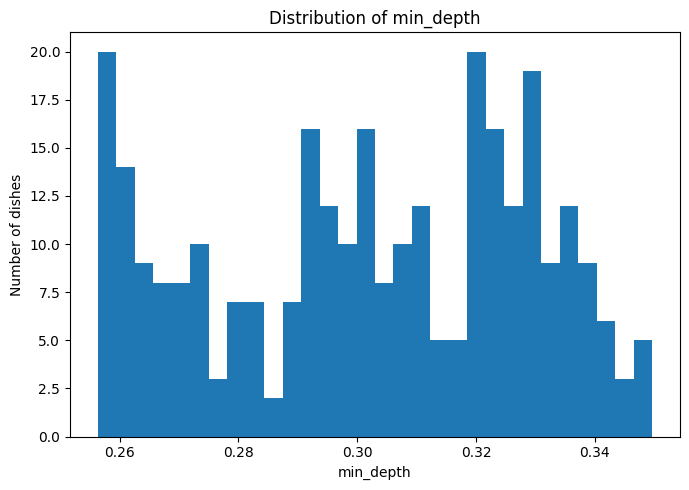

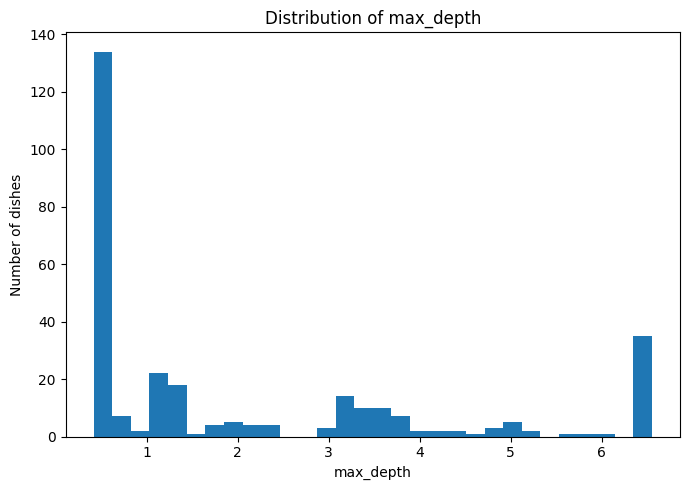

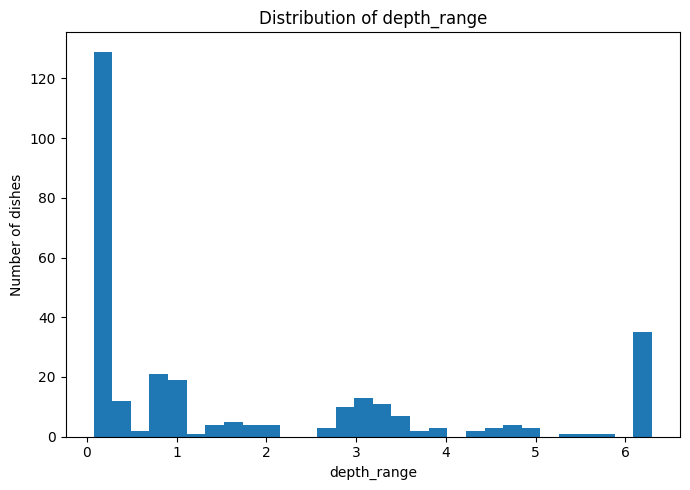

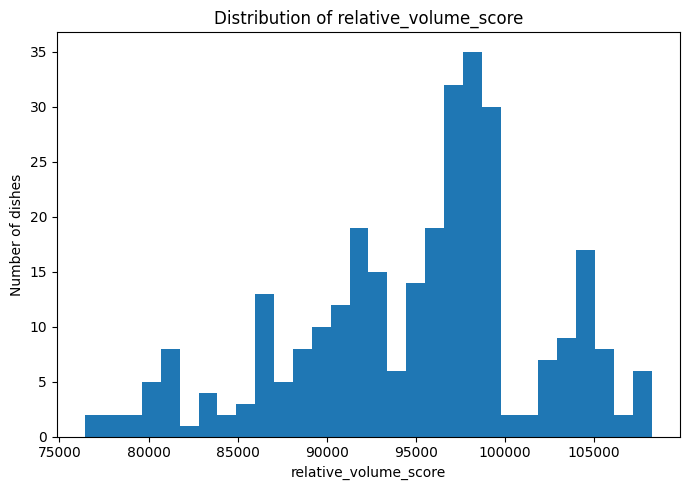

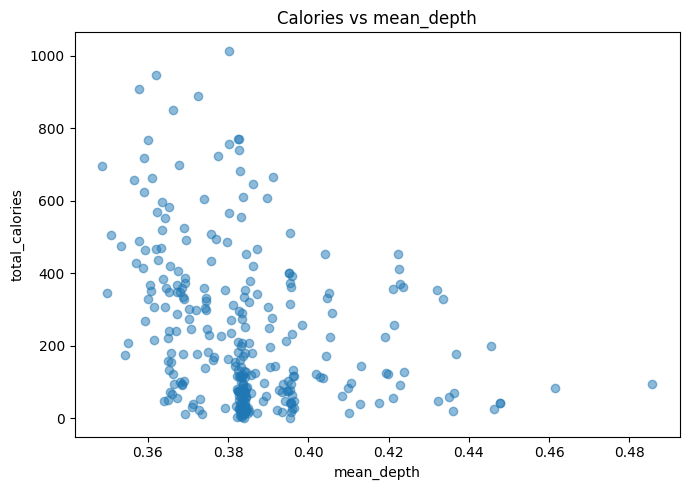

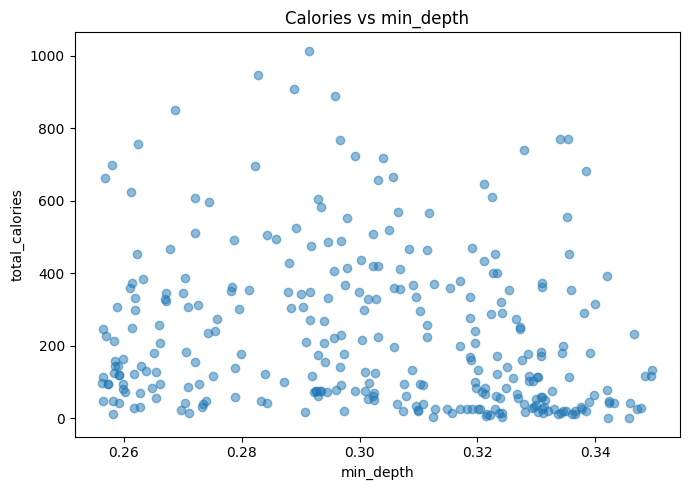

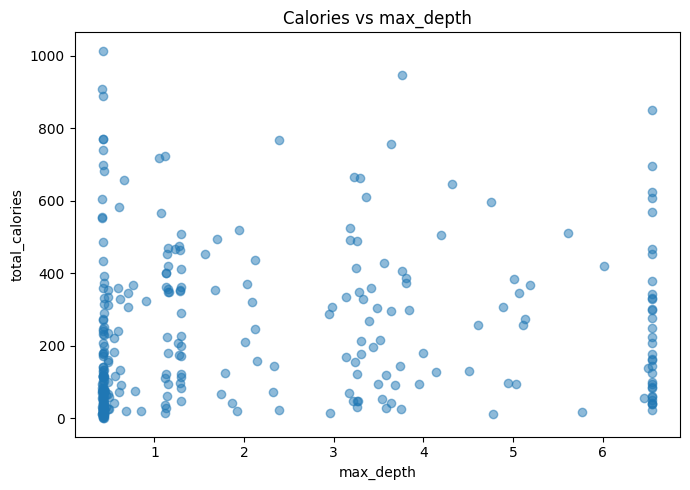

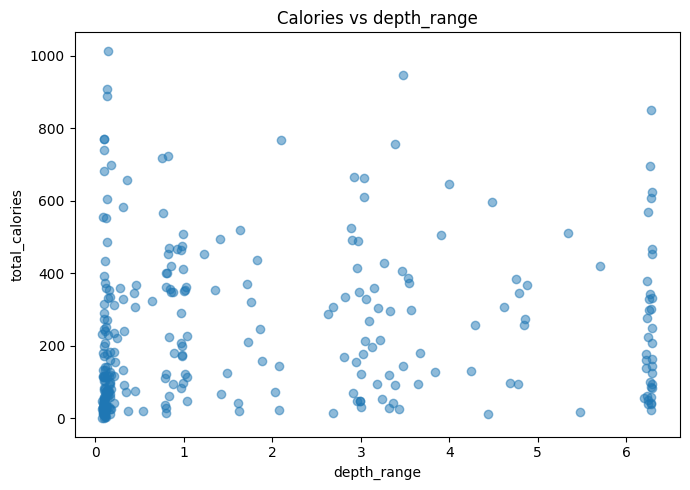

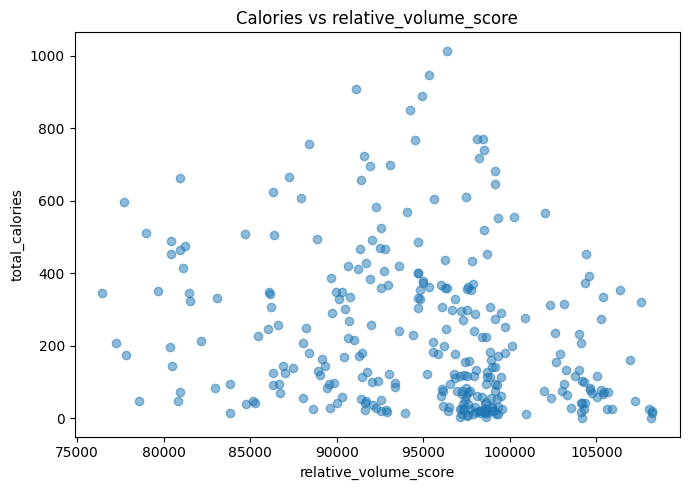

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_ROOT = "/content/drive/MyDrive/ML2026/data/nutrition5k_dataset"
CSV_PATH = "/content/drive/MyDrive/ML2026/data/metadata_clean.csv"
IMAGE_ROOT = os.path.join(DATA_ROOT, "imagery/realsense_overhead")

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print(df.head())
print(df.describe())

# -----------------------------
# 1. Nutrition target distributions
# -----------------------------
features = [
    "total_calories",
    "total_mass",
    "total_fat",
    "total_carb",
    "total_protein"
]

for feature in features:
    plt.figure(figsize=(7, 5))
    plt.hist(df[feature], bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of dishes")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 2. Correlation matrix
# -----------------------------
corr = df[features].corr()

plt.figure(figsize=(7, 6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(features)), features, rotation=45, ha="right")
plt.yticks(range(len(features)), features)

for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Between Nutrition Values")
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Calories vs macros scatter plots
# -----------------------------
for feature in ["total_mass", "total_fat", "total_carb", "total_protein"]:
    plt.figure(figsize=(7, 5))
    plt.scatter(df[feature], df["total_calories"], alpha=0.5)
    plt.title(f"Calories vs {feature}")
    plt.xlabel(feature)
    plt.ylabel("total_calories")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 4. Extract simple depth features
# -----------------------------
def find_depth_file(dish_id):
    dish_folder = os.path.join(IMAGE_ROOT, dish_id)

    if not os.path.exists(dish_folder):
        return None

    for file_name in os.listdir(dish_folder):
        lower_name = file_name.lower()
        full_path = os.path.join(dish_folder, file_name)

        if "depth_raw" in lower_name or ("depth" in lower_name and "color" not in lower_name):
            return full_path

    return None


depth_rows = []

# Use first 300 dishes for fast analysis
sample_df = df.head(300)

for _, row in sample_df.iterrows():
    dish_id = row["dish_id"]
    depth_path = find_depth_file(dish_id)

    if depth_path is None:
        continue

    depth = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)

    if depth is None:
        continue

    depth = depth.astype(np.float32) / 10000.0

    # remove invalid zero-depth pixels
    valid_depth = depth[depth > 0]

    if len(valid_depth) == 0:
        continue

    depth_rows.append({
        "dish_id": dish_id,
        "mean_depth": np.mean(valid_depth),
        "min_depth": np.min(valid_depth),
        "max_depth": np.max(valid_depth),
        "depth_range": np.max(valid_depth) - np.min(valid_depth),
        "relative_volume_score": np.sum(valid_depth),
        "total_calories": row["total_calories"],
        "total_mass": row["total_mass"],
        "total_fat": row["total_fat"],
        "total_carb": row["total_carb"],
        "total_protein": row["total_protein"]
    })

depth_df = pd.DataFrame(depth_rows)

print("\nDepth Feature Data:")
print(depth_df.head())
print(depth_df.describe())

depth_df.to_csv("/content/drive/MyDrive/ML2026/data/nutrition5k_dataset/depth_features.csv", index=False)

# -----------------------------
# 5. Depth feature distributions
# -----------------------------
depth_features = [
    "mean_depth",
    "min_depth",
    "max_depth",
    "depth_range",
    "relative_volume_score"
]

for feature in depth_features:
    plt.figure(figsize=(7, 5))
    plt.hist(depth_df[feature], bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of dishes")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 6. Depth vs calories
# -----------------------------
for feature in depth_features:
    plt.figure(figsize=(7, 5))
    plt.scatter(depth_df[feature], depth_df["total_calories"], alpha=0.5)
    plt.title(f"Calories vs {feature}")
    plt.xlabel(feature)
    plt.ylabel("total_calories")
    plt.tight_layout()
    plt.show()